In [1]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
año = "2024"
df = pd.read_csv(f"../Data/Raw Data/{año}_LoL_esports_match_data_from_OraclesElixir_preview.csv",low_memory=False)

In [4]:
print(df.info(True))

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 165 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    gameid                    str    
 1    datacompleteness          str    
 2    url                       str    
 3    league                    str    
 4    year                      int64  
 5    split                     float64
 6    playoffs                  int64  
 7    date                      str    
 8    game                      int64  
 9    patch                     float64
 10   participantid             int64  
 11   side                      str    
 12   position                  str    
 13   playername                str    
 14   playerid                  str    
 15   teamname                  str    
 16   teamid                    str    
 17   firstPick                 int64  
 18   champion                  str    
 19   ban1                      str    
 20   ban2                 

In [5]:
from sklearn.preprocessing import LabelEncoder
df_model = df.copy()
#Filas innecesarias: gameid, datacompleteness, url, league, date, playername, teamname
df_model = df_model.drop(["gameid","datacompleteness","url","league","date","playername","teamname"],axis=1)
#Filas a convertir:side, position, playerid, teamname, champion, ban-5, pick-5
# ============================
# 1. SIDE -> bool (0 = Blue, 1 = Red)
# ============================

df_model["side"] = df_model["side"].map({
    "Blue": 0,
    "Red": 1
}).astype("bool")

# ============================
# 2. POSITION -> One-Hot
# ============================

df_model = pd.get_dummies(
    df_model,
    columns=["position"],
    prefix="position",
    dtype=bool
)

# ============================
# 3. Label Encoding
# ============================

encoder = LabelEncoder()

columnas_label = [
    "playerid",
    "teamid",
    "champion",
    "ban1",
    "ban2",
    "ban3",
    "ban4",
    "ban5",
    "pick1",
    "pick2",
    "pick3",
    "pick4",
    "pick5"
]

for col in columnas_label:
    if col in df_model.columns:
        df_model[col] = encoder.fit_transform(
            df_model[col].astype(str)
        )

#print(df_model.dtypes)
print(df_model.info(True))

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 163 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    year                      int64  
 1    split                     float64
 2    playoffs                  int64  
 3    game                      int64  
 4    patch                     float64
 5    participantid             int64  
 6    side                      bool   
 7    playerid                  int64  
 8    teamid                    int64  
 9    firstPick                 int64  
 10   champion                  int64  
 11   ban1                      int64  
 12   ban2                      int64  
 13   ban3                      int64  
 14   ban4                      int64  
 15   ban5                      int64  
 16   pick1                     int64  
 17   pick2                     int64  
 18   pick3                     int64  
 19   pick4                     int64  
 20   pick5                

In [14]:
print(df_model.head())
#df_model = df_model.drop(["teamkills","teamdeaths"],axis=1)
X_train = df_model.drop("result",axis=1)
y_train = df_model["result"]

   year  split  playoffs  game  patch  participantid   side  playerid  teamid  \
0  2023    NaN         0     1  13.24              1  False         1       1   
1  2023    NaN         0     1  13.24              2  False         0       1   
2  2023    NaN         0     1  13.24              3  False         2       1   
3  2023    NaN         0     1  13.24              4  False         4       1   
4  2023    NaN         0     1  13.24              5  False         6       1   

   firstPick  ...  deathsat25  opp_killsat25  opp_assistsat25  opp_deathsat25  \
0          1  ...         NaN            NaN              NaN             NaN   
1          1  ...         NaN            NaN              NaN             NaN   
2          1  ...         NaN            NaN              NaN             NaN   
3          1  ...         NaN            NaN              NaN             NaN   
4          1  ...         NaN            NaN              NaN             NaN   

   position_bot  position_

In [15]:
from xgboost import XGBClassifier

modelo = XGBClassifier(random_state=42)
modelo.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


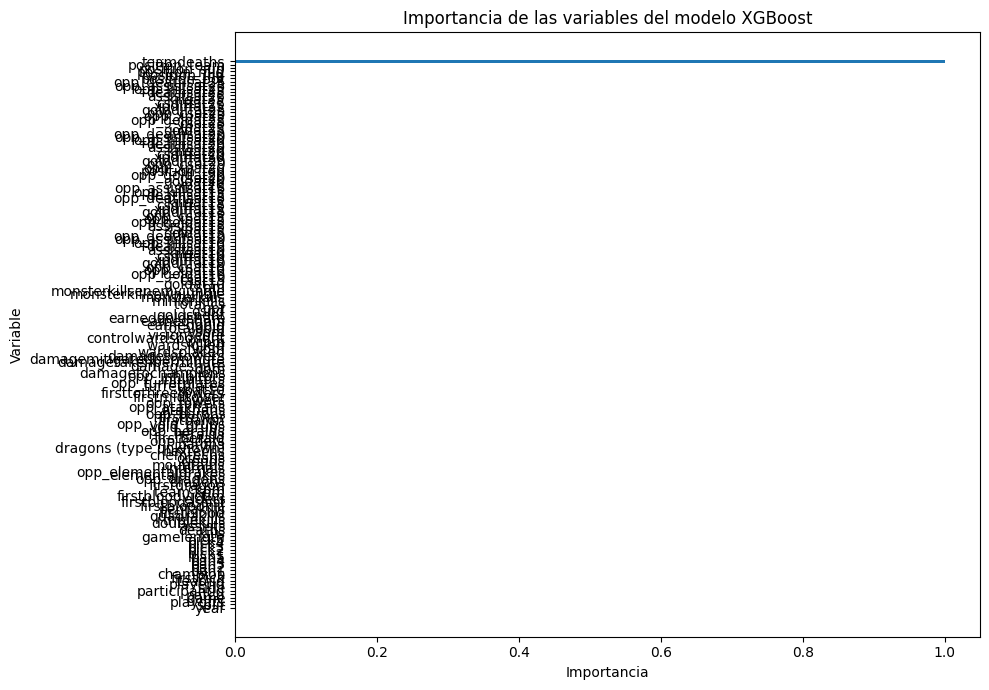

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Obtener importancia de las variables
importancias = modelo.feature_importances_

# Crear DataFrame
df_importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancias
})

# Ordenar
df_importancias = df_importancias.sort_values(
    by="Importancia",
    ascending=True
)

# Gráfico
plt.figure(figsize=(10,7))

plt.barh(
    df_importancias["Variable"],
    df_importancias["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de las variables del modelo XGBoost")

plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(
    shap_values,
    X_train,
    plot_type="bar"
)

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_train)

# Importancia media absoluta
importancia = np.abs(shap_values).mean(axis=0)

df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancia
})

df = df.sort_values("Importancia")

plt.figure(figsize=(10,7))

plt.barh(df["Variable"], df["Importancia"])

plt.xlabel("Valor SHAP medio")
plt.ylabel("Variable")
plt.title("Importancia de variables según SHAP")

plt.tight_layout()
plt.show()